Primero Realizamos un **EDA**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#Cargamos el dataset
df = pd.read_csv("ventas_empresa_logistica.csv")

Ver las primeras líneas

In [2]:
print(df.head())

        fecha  producto  categoria  cantidad  precio_unitario  total
0  2024-08-04  Frijoles     Granos         5              1.0    5.0
1  2024-09-01    Yogurt    Lácteos         2              1.1    2.2
2  2024-08-18       Pan  Panadería         4              0.5    2.0
3  2024-10-26  Frijoles     Granos         4              1.0    4.0
4  2024-08-12     Queso    Lácteos         2              2.5    5.0


📊 Paso 2: Análisis exploratorio de ventas
1. Productos más vendidos (por cantidad)

producto
Pollo           923
Yogurt          917
Jugo natural    910
Queso           906
Carne molida    892
Pan             892
Aceite          881
Frijoles        872
Leche           867
Arroz           819
Name: cantidad, dtype: int64


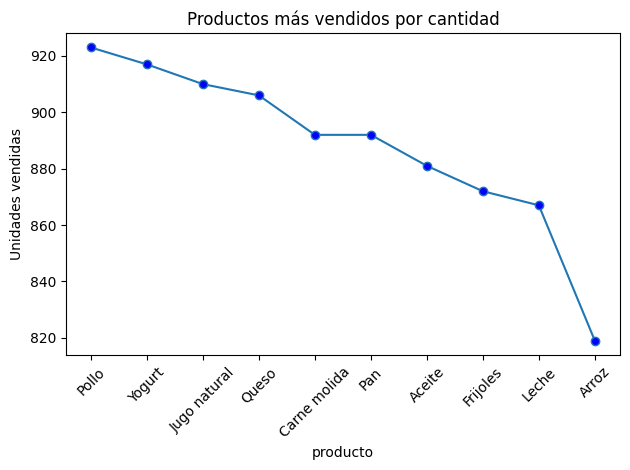

In [3]:
top_productos = df.groupby("producto")["cantidad"].sum().sort_values(ascending=False)
print(top_productos)

# Crear el gráfico y obtener el objeto `ax`
ax = top_productos.plot(
    kind="line",
    marker="o",
    markersize=6,
    markerfacecolor="blue",
    title="Productos más vendidos por cantidad",
    ylabel="Unidades vendidas"
)

# Mostrar todas las etiquetas del eje X
ax.set_xticks(range(len(top_productos)))
ax.set_xticklabels(top_productos.index, rotation=45)

plt.tight_layout()  # Ajustar el diseño para que no se corte nada
plt.show()

2. Productos con mayor ingreso (por total en dinero)

producto
Carne molida    3568.0
Pollo           3230.5
Queso           2265.0
Aceite          1762.0
Jugo natural    1638.0
Yogurt          1008.7
Arroz            982.8
Frijoles         872.0
Leche            780.3
Pan              446.0
Name: total, dtype: float64


<Axes: title={'center': 'Productos con mayores ingresos'}, xlabel='producto', ylabel='Total vendido ($)'>

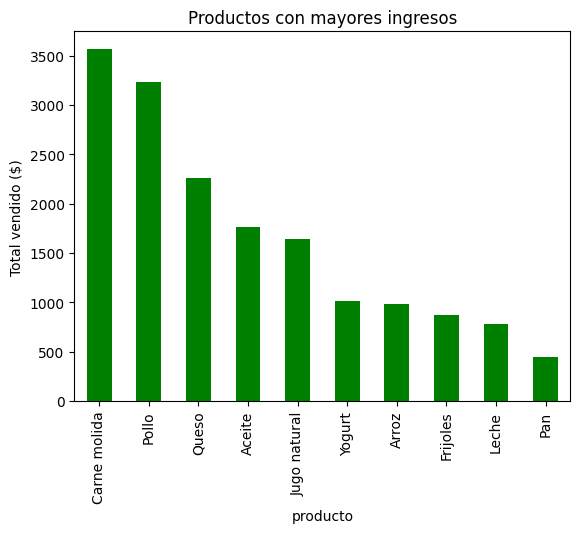

In [4]:
ingresos_productos = df.groupby("producto")["total"].sum().sort_values(ascending=False)
print(ingresos_productos)

ingresos_productos.plot(kind="bar", title="Productos con mayores ingresos", ylabel="Total vendido ($)", color='green')


3. Tendencia de ventas a lo largo del tiempo
Primero convertimos la fecha a tipo datetime:

<Axes: title={'center': 'Tendencia mensual de ingresos'}, xlabel='fecha', ylabel='Total mensual ($)'>

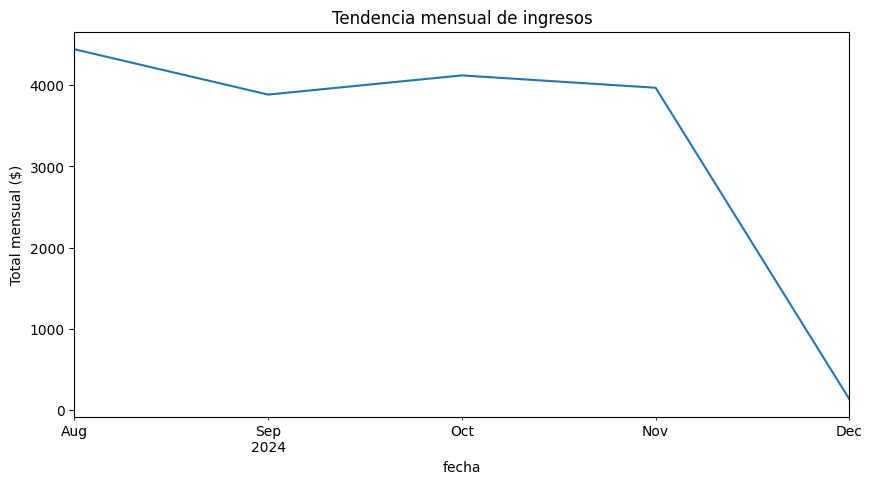

In [5]:
df["fecha"] = pd.to_datetime(df["fecha"])
ventas_por_mes = df.resample("ME", on="fecha")["total"].sum()

ventas_por_mes.plot(title="Tendencia mensual de ingresos", ylabel="Total mensual ($)", figsize=(10, 5))


4. Ventas por categoría

<Axes: title={'center': 'Ventas por categoría'}, xlabel='Cantidad vendida', ylabel='categoria'>

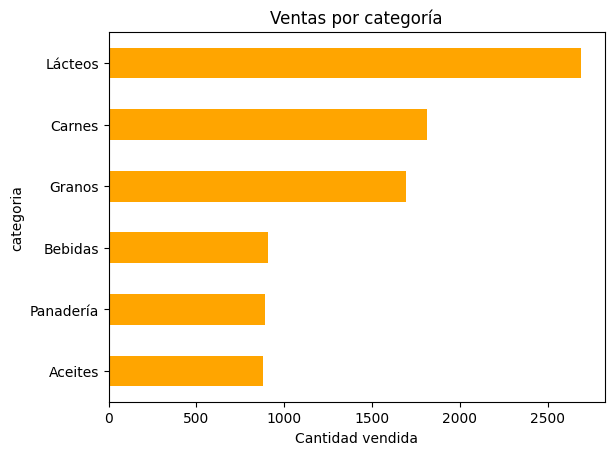

In [6]:
df.groupby("categoria")["cantidad"].sum().sort_values().plot(
    kind="barh", title="Ventas por categoría", xlabel="Cantidad vendida", color='orange'
)


📊 3. Transformar el dataset para modelado
•	Necesitamos agrupar las ventas por mes y por producto:

In [7]:
import pandas as pd

# Cargar y preparar
df = pd.read_csv("ventas_empresa_logistica.csv", parse_dates=["fecha"])
df["año_mes"] = df["fecha"].dt.to_period("M")

# Agrupación por producto y mes
ventas_mensuales = df.groupby(["producto", "año_mes"]).agg({
    "cantidad": "sum"
}).reset_index()

# Convertimos año_mes a fecha
ventas_mensuales["fecha"] = ventas_mensuales["año_mes"].dt.to_timestamp()
ventas_mensuales = ventas_mensuales.sort_values(by=["producto", "fecha"])


Mostrar cómo se comportaron las ventas a lo largo del tiempo.

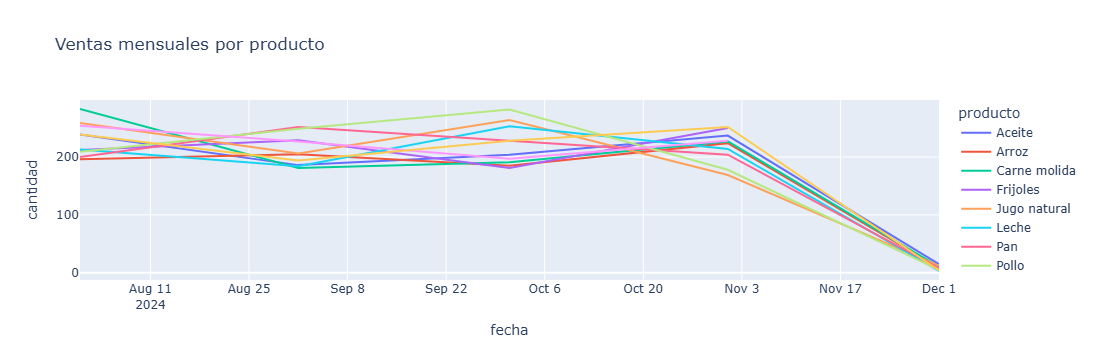

In [8]:
import plotly.express as px

fig = px.line(ventas_mensuales, x="fecha", y="cantidad", color="producto", title="Ventas mensuales por producto")
fig.show()
